# 04 — Raw and smoothed Dupire baselines

Stage 3 created noisy synthetic option quotes from a known local-volatility
surface.

This notebook tries to recover local volatility directly from those prices.

In log-moneyness coordinates,

$$
x=\log\left(\frac{K}{F(T)}\right),
$$

the direct Dupire formula is

$$
\sigma_{\mathrm{loc}}^2(x,T)
=
\frac{
2\left(
\frac{\partial C}{\partial T}
+
qC
\right)
}{
\frac{\partial^2 C}{\partial x^2}
-
\frac{\partial C}{\partial x}
}.
$$

We compare:

1. **raw Dupire** — differentiate the noisy quotes directly;
2. **smoothed Dupire** — smooth prices first, then differentiate.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    if (project_root.parent / "src").exists():
        project_root = project_root.parent
    else:
        raise FileNotFoundError(
            "Could not find the project root. Start Jupyter from the "
            "dupire_local_vol_project folder."
        )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)


Project root: /mnt/data/dupire_audit/dupire_local_vol_project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.synthetic_data import (
    generate_synthetic_option_data,
    save_synthetic_option_data,
)
from src.dupire.direct_dupire import (
    raw_dupire_from_quotes,
    smoothed_dupire_from_quotes,
)
from src.surfaces.synthetic_surfaces import smile_surface


## 1. Load the Stage 3 synthetic quotes

If the CSV has not yet been created, this notebook regenerates the same
dataset using the same seed and saves it.


In [3]:
data_path = (
    project_root
    / "data"
    / "synthetic"
    / "smile_quotes.csv"
)

if data_path.exists():
    synthetic_quotes = pd.read_csv(data_path)
    print("Loaded:", data_path)
else:
    synthetic_quotes = generate_synthetic_option_data(
        surface_function=smile_surface,
        spot=100.0,
        relative_noise=0.005,
        minimum_noise=0.01,
        random_seed=1234,
        number_of_strike_points=301,
        number_of_time_steps=300,
    )
    save_synthetic_option_data(
        synthetic_quotes,
        data_path,
    )
    print("Generated and saved:", data_path)

print("Number of quotes:", len(synthetic_quotes))
synthetic_quotes.head()


Loaded: /mnt/data/dupire_audit/dupire_local_vol_project/data/synthetic/smile_quotes.csv
Number of quotes: 78


,maturity,log_moneyness,forward,strike,true_local_volatility,true_call_price,noise_standard_deviation,noise,observed_call_price,call_lower_bound,call_upper_bound
0,0.1,-0.30,100.0,74.081822,0.229425,25.918212,0.129591,-0.000034,25.918178,25.918178,100.0
1,0.1,-0.25,100.0,77.880078,0.227225,22.120423,0.110602,0.007090,22.127513,22.119922,100.0
2,0.1,-0.20,100.0,81.873075,0.225425,18.132482,0.090662,0.067171,18.199653,18.126925,100.0
3,0.1,-0.15,100.0,86.070798,0.224025,13.973593,0.069868,0.010663,13.984256,13.929202,100.0
4,0.1,-0.10,100.0,90.483742,0.223025,9.768884,0.048844,0.042189,9.811073,9.516258,100.0


## 2. Why raw Dupire is fragile

The denominator is

$$
C_{xx}-C_x.
$$

The term $C_{xx}$ is a second derivative. Finite differences estimate it
using neighbouring prices. Small quote errors can therefore produce large
changes in the recovered local variance.

Invalid points are kept as `NaN`; we do not hide them by clipping volatility.


In [4]:
raw_result = raw_dupire_from_quotes(
    quote_data=synthetic_quotes,
    price_column="observed_call_price",
    dividend_yield=0.0,
)

truth_columns = synthetic_quotes[
    [
        "maturity",
        "log_moneyness",
        "true_local_volatility",
    ]
]

raw_result = raw_result.merge(
    truth_columns,
    on=["maturity", "log_moneyness"],
    how="left",
)

raw_valid_fraction = raw_result["valid_dupire"].mean()

print(
    "Raw Dupire valid fraction:",
    f"{raw_valid_fraction:.2%}",
)


Raw Dupire valid fraction: 93.59%


## 3. Raw recovered local volatility

Blank regions are points where the direct formula produced a non-positive
denominator, non-positive variance, or another invalid numerical value.


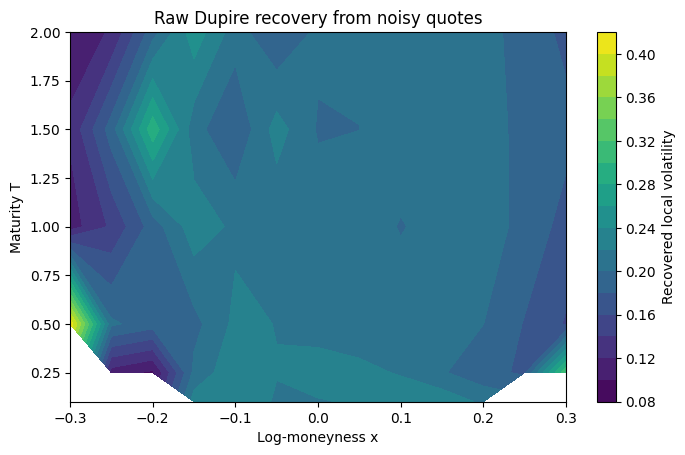

In [5]:
raw_maturities = np.sort(
    raw_result["maturity"].unique()
)
raw_x = np.sort(
    raw_result["log_moneyness"].unique()
)
raw_volatility = raw_result.pivot(
    index="maturity",
    columns="log_moneyness",
    values="local_volatility",
).reindex(
    index=raw_maturities,
    columns=raw_x,
).to_numpy()

plt.figure(figsize=(8, 4.8))
contour = plt.contourf(
    raw_x,
    raw_maturities,
    raw_volatility,
    levels=20,
)
plt.colorbar(contour, label="Recovered local volatility")
plt.xlabel("Log-moneyness x")
plt.ylabel("Maturity T")
plt.title("Raw Dupire recovery from noisy quotes")
plt.show()


## 4. Smooth the prices before differentiating

The smoothing baseline uses two passes of weighted cubic splines:

1. across log-moneyness at each maturity;
2. across maturity at each log-moneyness value.

The quote-noise standard deviations from Stage 3 are used as weights.

This is only a baseline. It is not yet the operator-regularised inverse method.


In [6]:
smoothed_result = smoothed_dupire_from_quotes(
    quote_data=synthetic_quotes,
    price_column="observed_call_price",
    noise_column="noise_standard_deviation",
    dividend_yield=0.0,
    x_smoothing_multiplier=0.5,
    time_smoothing_multiplier=1.0,
)

smoothed_result = smoothed_result.merge(
    truth_columns,
    on=["maturity", "log_moneyness"],
    how="left",
)

smoothed_valid_fraction = (
    smoothed_result["valid_dupire"].mean()
)

print(
    "Smoothed Dupire valid fraction:",
    f"{smoothed_valid_fraction:.2%}",
)


Smoothed Dupire valid fraction: 94.87%


## 5. Inspect the smoothed price curves

The points are noisy observed quotes. The lines are the prices used by
smoothed Dupire.


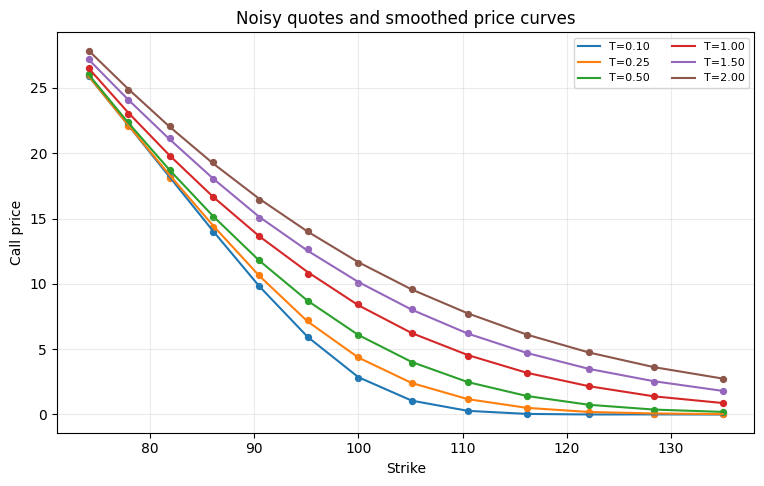

In [7]:
plt.figure(figsize=(9, 5.2))

for maturity in np.sort(
    synthetic_quotes["maturity"].unique()
):
    observed_slice = synthetic_quotes[
        np.isclose(
            synthetic_quotes["maturity"],
            maturity,
        )
    ].sort_values("strike")

    smoothed_slice = smoothed_result[
        np.isclose(
            smoothed_result["maturity"],
            maturity,
        )
    ].sort_values("log_moneyness")

    plt.scatter(
        observed_slice["strike"],
        observed_slice["observed_call_price"],
        s=18,
    )
    plt.plot(
        observed_slice["strike"],
        smoothed_slice["price_used"],
        label=f"T={maturity:.2f}",
    )

plt.xlabel("Strike")
plt.ylabel("Call price")
plt.title("Noisy quotes and smoothed price curves")
plt.legend(ncol=2, fontsize=8)
plt.grid(alpha=0.25)
plt.show()


## 6. Smoothed recovered local volatility

Smoothing usually removes many of the extreme oscillations, but it introduces
a new tuning choice: how much smoothing should be used?


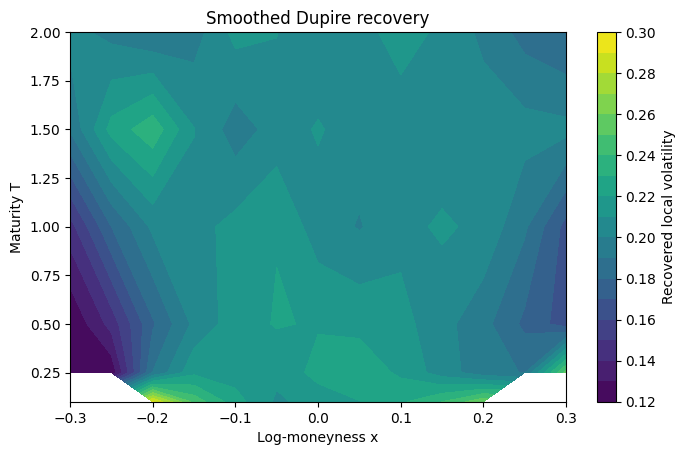

In [8]:
smooth_maturities = np.sort(
    smoothed_result["maturity"].unique()
)
smooth_x = np.sort(
    smoothed_result["log_moneyness"].unique()
)
smooth_volatility = smoothed_result.pivot(
    index="maturity",
    columns="log_moneyness",
    values="local_volatility",
).reindex(
    index=smooth_maturities,
    columns=smooth_x,
).to_numpy()

plt.figure(figsize=(8, 4.8))
contour = plt.contourf(
    smooth_x,
    smooth_maturities,
    smooth_volatility,
    levels=20,
)
plt.colorbar(contour, label="Recovered local volatility")
plt.xlabel("Log-moneyness x")
plt.ylabel("Maturity T")
plt.title("Smoothed Dupire recovery")
plt.show()


## 7. Compare with the known truth

For a fair comparison, the RMSE below uses points where both methods produced
valid local volatility.


In [9]:
comparison = raw_result[
    [
        "maturity",
        "log_moneyness",
        "local_volatility",
        "valid_dupire",
        "true_local_volatility",
    ]
].rename(
    columns={
        "local_volatility": "raw_volatility",
        "valid_dupire": "raw_valid",
    }
).merge(
    smoothed_result[
        [
            "maturity",
            "log_moneyness",
            "local_volatility",
            "valid_dupire",
        ]
    ].rename(
        columns={
            "local_volatility": "smoothed_volatility",
            "valid_dupire": "smoothed_valid",
        }
    ),
    on=["maturity", "log_moneyness"],
    how="inner",
)

shared_valid = (
    comparison["raw_valid"]
    & comparison["smoothed_valid"]
)

raw_rmse = np.sqrt(
    np.mean(
        (
            comparison.loc[
                shared_valid,
                "raw_volatility",
            ]
            - comparison.loc[
                shared_valid,
                "true_local_volatility",
            ]
        ) ** 2
    )
)

smoothed_rmse = np.sqrt(
    np.mean(
        (
            comparison.loc[
                shared_valid,
                "smoothed_volatility",
            ]
            - comparison.loc[
                shared_valid,
                "true_local_volatility",
            ]
        ) ** 2
    )
)

print(
    "Shared valid points:",
    int(shared_valid.sum()),
    "out of",
    len(comparison),
)
print(f"Raw Dupire RMSE:      {raw_rmse:.6f}")
print(f"Smoothed Dupire RMSE: {smoothed_rmse:.6f}")


Shared valid points: 72 out of 78
Raw Dupire RMSE:      0.044205
Smoothed Dupire RMSE: 0.024996


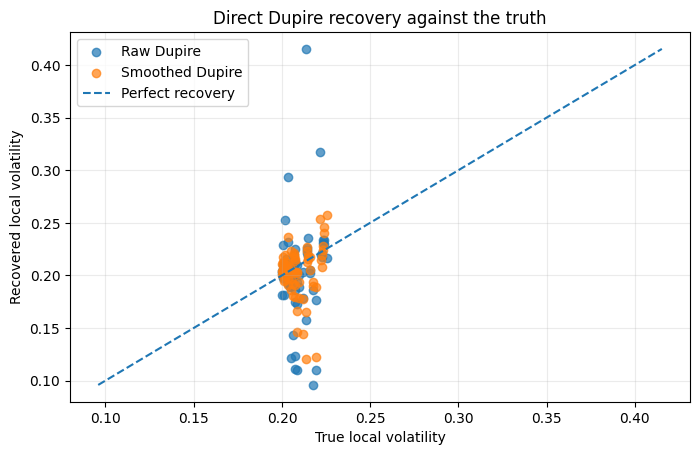

In [10]:
plt.figure(figsize=(8, 4.8))

plt.scatter(
    comparison.loc[shared_valid, "true_local_volatility"],
    comparison.loc[shared_valid, "raw_volatility"],
    label="Raw Dupire",
    alpha=0.7,
)

plt.scatter(
    comparison.loc[shared_valid, "true_local_volatility"],
    comparison.loc[shared_valid, "smoothed_volatility"],
    label="Smoothed Dupire",
    alpha=0.7,
)

minimum_value = comparison.loc[
    shared_valid,
    [
        "true_local_volatility",
        "raw_volatility",
        "smoothed_volatility",
    ],
].min().min()

maximum_value = comparison.loc[
    shared_valid,
    [
        "true_local_volatility",
        "raw_volatility",
        "smoothed_volatility",
    ],
].max().max()

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    label="Perfect recovery",
)

plt.xlabel("True local volatility")
plt.ylabel("Recovered local volatility")
plt.title("Direct Dupire recovery against the truth")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 8. Main conclusion

Raw Dupire applies numerical differentiation directly to noisy prices. The
second derivative amplifies noise, causing unstable or invalid volatility.

Smoothing helps, but it has limitations:

- the smoothing strength must be chosen;
- too little smoothing leaves noise;
- too much smoothing removes genuine surface structure;
- price smoothing is not the same as directly regularising the inverse problem.

The next stage builds the regularisation operators that will act directly on
the local-volatility correction.
